# 07 — Volume Confirmation

## Concept
Not all displacements are equal. A displacement on 3× average volume is
far more significant than one on 0.5× volume.

High volume = real institutional participation.
Low volume  = thin-market noise, easily reversed.

## Hypothesis
OBs formed during high-volume displacements should:
- Have more follow-through on retest
- Be less likely to be invalidated by opposing flow

## What we measure
- Distribution of volume during displacement segments
- Impact on signal quality when volume > 1.3× MA required

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.ob_core import add_candle_features, _detect_displacements
from strategy.volume.confirmation import (
    compute_volume_context, add_volume_columns, displacement_has_volume
)
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 6)})

SYMBOL = 'XAUUSDT'
RISK   = 20.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = add_candle_features(m5.sort_index())
m5 = add_volume_columns(m5, ma_period=20, spike_multiplier=1.5)

print(f'Loaded {len(m5):,} M5 bars')
print(f'Volume spikes (>1.5x MA): {m5["volume_spike"].sum():,} bars ({m5["volume_spike"].mean()*100:.1f}%)')

Loaded 19,798 M5 bars
Volume spikes (>1.5x MA): 3,925 bars (19.8%)


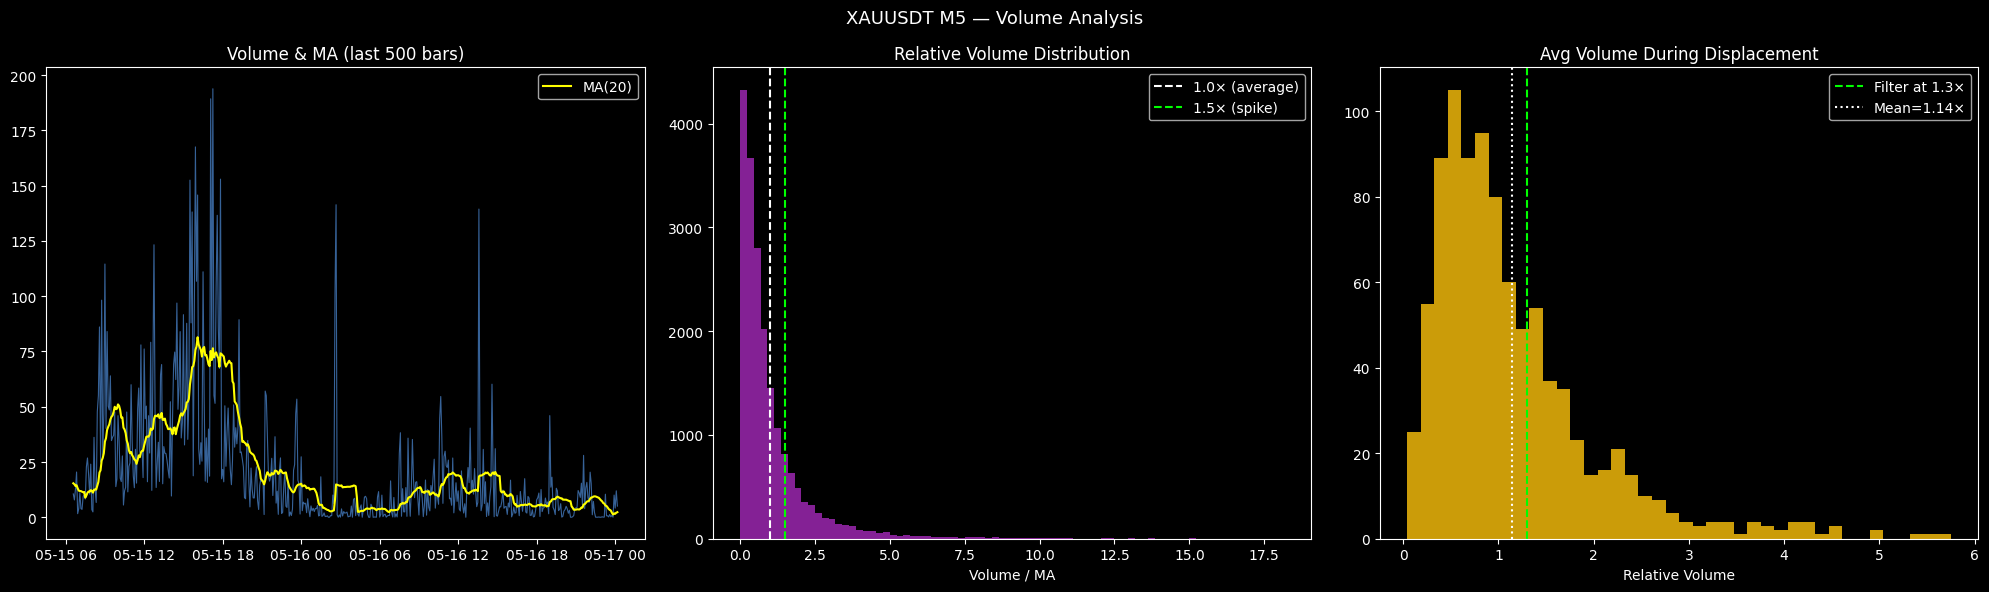


Displacements with avg volume > 1.3×: 290 / 930


In [2]:
# ── Volume distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Raw volume
axes[0].plot(m5.index[-500:], m5['volume'].iloc[-500:], color='#4E8CD9', linewidth=0.8, alpha=0.7)
axes[0].plot(m5.index[-500:], m5['volume_ma'].iloc[-500:], color='yellow', linewidth=1.5, label='MA(20)')
axes[0].set_title('Volume & MA (last 500 bars)')
axes[0].legend()

# Relative volume distribution
axes[1].hist(m5['volume_ratio'].dropna(), bins=80, color='#9C27B0', edgecolor='none', alpha=0.85)
axes[1].axvline(1.0, color='white', linestyle='--', label='1.0× (average)')
axes[1].axvline(1.5, color='lime',  linestyle='--', label='1.5× (spike)')
axes[1].set_title('Relative Volume Distribution')
axes[1].set_xlabel('Volume / MA')
axes[1].legend()

# Volume during displacements
displacements = _detect_displacements(m5, min_candles=4, atr_mult=1.5)
vol_ctx = compute_volume_context(m5)

disp_avg_ratios = []
for d in displacements:
    end_idx = min(d.start_idx + 4, len(m5))
    avg_ratio = float(vol_ctx.volume_ratio.iloc[d.start_idx:end_idx].mean())
    disp_avg_ratios.append(avg_ratio)

axes[2].hist(disp_avg_ratios, bins=40, color='#F0B90B', edgecolor='none', alpha=0.85)
axes[2].axvline(1.3, color='lime', linestyle='--', label='Filter at 1.3×')
axes[2].axvline(np.mean(disp_avg_ratios), color='white', linestyle=':',
                label=f'Mean={np.mean(disp_avg_ratios):.2f}×')
axes[2].set_title('Avg Volume During Displacement')
axes[2].set_xlabel('Relative Volume')
axes[2].legend()

plt.suptitle(f'{SYMBOL} M5 — Volume Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nDisplacements with avg volume > 1.3×: {sum(r > 1.3 for r in disp_avg_ratios)} / {len(disp_avg_ratios)}')

In [3]:
# ── Compare signals with and without volume filter ─────────────────────────
cfg_base = OBSignalConfig(rr=2.0)
cfg_vol  = OBSignalConfig(rr=2.0, volume_filter_enabled=True,
                          volume_ma_period=20, volume_multiplier=1.3)

sigs_base = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_base)
sigs_vol  = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_vol)
sigs_vol_pass = get_passed_signals(sigs_vol)

print(f'Baseline signals    : {len(sigs_base)}')
print(f'Volume-filtered     : {len(sigs_vol_pass)}')
pct = (1 - len(sigs_vol_pass) / max(len(sigs_base), 1)) * 100
print(f'Reduction           : {pct:.1f}%')
print('\nKey question: does removing {pct:.0f}% of signals improve expectancy?')
print('Answer in notebook 12.')

Baseline signals    : 290
Volume-filtered     : 91
Reduction           : 68.6%

Key question: does removing {pct:.0f}% of signals improve expectancy?
Answer in notebook 12.
